# Task 2: Medical Report Generation

---
### Quick Setup: I run it on cloab due to GPU requriements. 
```bash
conda create -n medx python=3.10 -y
conda activate medx
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118
pip install transformers>=4.40.0 accelerate bitsandbytes medmnist \
            Pillow sentencepiece protobuf python-dotenv
jupyter notebook
```

In [1]:
# setting path and load prestored results for comparison
import os
REPO_URL  = 'https://github.com/Irshadcsit/ProjectX.git'   # ← updated
REPO_NAME = 'ProjectX'                                     # ← updated

if not os.path.exists(REPO_NAME):
    !git clone {REPO_URL}


os.chdir(REPO_NAME)
import sys; sys.path.insert(0, '.')
print('Repo ready. CWD:', os.getcwd())

Repo ready. CWD: /content/ProjectX


In [22]:
OUTPUT_DIR = 'outputs/task2'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs('reports', exist_ok=True)

print('✓ All imports successful')

✓ All imports successful


In [23]:
import os
print(os.getcwd())

/content/ProjectX


In [24]:
print(f"Your notebook is running in: {os.getcwd()}")
print(f"Folders Python can see: {os.listdir('.')}")

Your notebook is running in: /content/ProjectX
Folders Python can see: ['ProjectX', 'models', '.ipynb_checkpoints', 'Main_notebook.ipynb', '.git', '01_train_classifier.ipynb', 'data', '.env', 'README.md', '.gitattributes', 'requirements.txt', 'reports', 'Classification', 'data_analysis', 'task2_colab.ipynb', '01_evaluate_classifier.ipynb', '01_data_analysis.ipynb', 'task1_classification_report.md', 'outputs', 'git']


## 0. Environment Check & GPU Diagnostics

In [2]:
!pip install medmnist
!pip install bitsandbytes

In [ ]:
## 1. HuggingFace Authentication

**Option A (recommended):** Create a `.env` file in the same folder as this notebook:
```
HF_TOKEN=hf_your_token_here
```

**Option B:** For Colab add token to secret (never commit to GitHub).

Get token: https://huggingface.co/settings/tokens  
Accept license: https://huggingface.co/google/medgemma-4b-it

In [4]:
from google.colab import userdata
import os

# 1. Access the secret key loaded from 
hf_token = userdata.get('medenv')

# 2. Set it for the environment (optional, but helpful for many libraries)
os.environ["HF_TOKEN"] = hf_token

print("✅ Secret key 'medenv' accessed and loaded.")

✅ Secret key 'medenv' accessed and loaded.


In [5]:
import torch, json, os, textwrap, time
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from torchvision import transforms
from medmnist import PneumoniaMNIST

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

OUTPUT_DIR = 'outputs/task2'
os.makedirs(OUTPUT_DIR, exist_ok=True)
CLASS_NAMES = ['Normal', 'Pneumonia']

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [28]:
import os
import json
import numpy as np

# 1. load resnet results
CNN_RESULTS_PATH = 'outputs/resnet/test_metrics.json'

# 2. Re-run the loading logic
cnn_predictions = None

if os.path.exists(CNN_RESULTS_PATH):
    with open(CNN_RESULTS_PATH) as f:
        cnn_data = json.load(f)

    # Check if the key is 'predictions' or 'preds'
    # Many MedMNIST scripts save them as a list
    cnn_predictions = np.array(cnn_data.get('predictions', []))

    if len(cnn_predictions) > 0:
        print(f'✅ Success! Loaded {len(cnn_predictions)} CNN predictions.')
    else:
        print(' File found, but "predictions" key is empty.')
        cnn_predictions = None
else:
    print(f'❌ File NOT found at: {os.path.abspath(CNN_RESULTS_PATH)}')
    print(f'Available in outputs: {os.listdir("outputs") if os.path.exists("outputs") else "outputs folder missing"}')

# 3. If it failed, the simulation code below in your original snippet will now take over

✅ Success! Loaded 624 CNN predictions.


In [29]:
#cnn_predictions

array([1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,

In [30]:
# ── Load test set (raw, no normalization — VLM needs PIL images) ───────────
raw_transform = transforms.ToTensor()
test_ds = PneumoniaMNIST(split='test', transform=raw_transform, download=True, size=28)
print(f'Test set: {len(test_ds)} images')

# ── Try to load CNN predictions from Task 1 ───────────────────────────────
CNN_PATHS = [
    'outputs/resnet/test_metrics.json',
]

#cnn_predictions = None
if os.path.exists(CNN_RESULTS_PATH):
    with open(CNN_RESULTS_PATH) as f:
        cnn_data = json.load(f)
    cnn_predictions = np.array(cnn_data.get('predictions', []))
    print(f'✓ Loaded CNN predictions from Task 1 ({len(cnn_predictions)} samples)')
else:
    print(' No Task 1 CNN predictions found — using ground truth labels for sampling')
    print(f'  (Expected path: {CNN_RESULTS_PATH})')
    print('  Will simulate CNN predictions = ground truth for demonstration')

# ── Extract labels ─────────────────────────────────────────────────────────
all_labels = np.array([int(test_ds[i][1]) for i in range(len(test_ds))])

if cnn_predictions is None:
    # Simulate: assume CNN is correct on most but has some errors
    cnn_predictions = all_labels.copy()
    # Inject simulated errors for demonstration
    normal_idx_all    = np.where(all_labels == 0)[0]
    pneumonia_idx_all = np.where(all_labels == 1)[0]
    np.random.seed(42)
    # Flip 5% of each class to simulate errors
    for idx in np.random.choice(normal_idx_all,    size=max(1, len(normal_idx_all)//20),    replace=False):
        cnn_predictions[idx] = 1
    for idx in np.random.choice(pneumonia_idx_all, size=max(1, len(pneumonia_idx_all)//20), replace=False):
        cnn_predictions[idx] = 0
    print('  Simulated CNN predictions created for demonstration')

# ── Categorize samples ─────────────────────────────────────────────────────
true_normal_idx    = np.where((all_labels == 0) & (cnn_predictions == 0))[0]
true_pneumonia_idx = np.where((all_labels == 1) & (cnn_predictions == 1))[0]
false_pos_idx      = np.where((all_labels == 0) & (cnn_predictions == 1))[0]  # FP
false_neg_idx      = np.where((all_labels == 1) & (cnn_predictions == 0))[0]  # FN

print(f'\nSample pool:')
print(f'  True Normal (TN):    {len(true_normal_idx)}')
print(f'  True Pneumonia (TP): {len(true_pneumonia_idx)}')
print(f'  False Positive (FP): {len(false_pos_idx)}')
print(f'  False Negative (FN): {len(false_neg_idx)}')

Test set: 624 images
✓ Loaded CNN predictions from Task 1 (624 samples)

Sample pool:
  True Normal (TN):    169
  True Pneumonia (TP): 389
  False Positive (FP): 65
  False Negative (FN): 1


In [31]:
# ── Select 12 representative images ───────────────────────────────────────
np.random.seed(42)

n_fp = min(2, len(false_pos_idx))
n_fn = min(2, len(false_neg_idx))
n_tn = min(4, len(true_normal_idx))
n_tp = 12 - n_tn - n_fp - n_fn   # fill remaining with true pneumonia

selected = [
    *[(i, 'True Normal',     0, 0) for i in np.random.choice(true_normal_idx,    n_tn, replace=False)],
    *[(i, 'True Pneumonia',  1, 1) for i in np.random.choice(true_pneumonia_idx, n_tp, replace=False)],
    *[(i, 'False Positive',  0, 1) for i in (np.random.choice(false_pos_idx, n_fp, replace=False) if n_fp > 0 else [])],
    *[(i, 'False Negative',  1, 0) for i in (np.random.choice(false_neg_idx, n_fn, replace=False) if n_fn > 0 else [])],
]

print(f'Selected {len(selected)} images for report generation:')
for idx, cat, gt, cnn_pred in selected:
    print(f'  img_{idx:04d}  {cat:<18}  GT={CLASS_NAMES[gt]}  CNN={CLASS_NAMES[cnn_pred]}')


def tensor_to_pil(tensor_img, upscale_to=224):
    """Convert 28x28 grayscale tensor to RGB PIL image suitable for VLMs."""
    img_np = tensor_img.squeeze().numpy()
    img_np = (img_np * 255).astype(np.uint8)
    pil    = Image.fromarray(img_np, mode='L').convert('RGB')
    pil    = pil.resize((upscale_to, upscale_to), Image.LANCZOS)
    return pil

Selected 12 images for report generation:
  img_0501  True Normal         GT=Normal  CNN=Normal
  img_0112  True Normal         GT=Normal  CNN=Normal
  img_0446  True Normal         GT=Normal  CNN=Normal
  img_0106  True Normal         GT=Normal  CNN=Normal
  img_0413  True Pneumonia      GT=Pneumonia  CNN=Pneumonia
  img_0016  True Pneumonia      GT=Pneumonia  CNN=Pneumonia
  img_0381  True Pneumonia      GT=Pneumonia  CNN=Pneumonia
  img_0512  True Pneumonia      GT=Pneumonia  CNN=Pneumonia
  img_0344  True Pneumonia      GT=Pneumonia  CNN=Pneumonia
  img_0565  False Positive      GT=Normal  CNN=Pneumonia
  img_0378  False Positive      GT=Normal  CNN=Pneumonia
  img_0148  False Negative      GT=Pneumonia  CNN=Normal


In [ ]:
#!pip install python-dotenv

In [9]:
from transformers import (
    AutoProcessor, AutoModelForImageTextToText,
    BitsAndBytesConfig, pipeline
)
import warnings
warnings.filterwarnings('ignore')

# ── 4-bit quantization config for memory efficiency ────────────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4'
)

MODEL_USED = None
processor  = None
vlm_model  = None

# ── Try MedGemma first ─────────────────────────────────────────────────────
#MEDGEMMA_ID = 'google/medgemma-4b-it'
LLAVA_ID    = 'llava-hf/llava-1.5-7b-hf'

if HF_TOKEN:
    try:
        print(f'Loading MedGemma ({MEDGEMMA_ID})...')
        print('This may take 5–10 minutes on first run (downloading ~8GB)...')
        processor = AutoProcessor.from_pretrained(
            MEDGEMMA_ID, token=HF_TOKEN)
        vlm_model = AutoModelForImageTextToText.from_pretrained(
            MEDGEMMA_ID,
            quantization_config=bnb_config,
            device_map='auto',
            token=HF_TOKEN
        )
        MODEL_USED = 'MedGemma-4B-IT'
        print(f'✓ {MODEL_USED} loaded successfully')
    except Exception as e:
        print(f'⚠ MedGemma failed: {e}')
        print('→ Falling back to LLaVA-1.5-7B')

# ── Fallback: LLaVA-1.5-7B ────────────────────────────────────────────────
if vlm_model is None:
    try:
        print(f'\nLoading LLaVA-1.5-7B ({LLAVA_ID})...')
        print('Downloading ~14GB on first run...')
        processor = AutoProcessor.from_pretrained(LLAVA_ID)
        vlm_model = AutoModelForImageTextToText.from_pretrained(
            LLAVA_ID,
            quantization_config=bnb_config,
            device_map='auto'
        )
        MODEL_USED = 'LLaVA-1.5-7B'
        print(f'✓ {MODEL_USED} loaded successfully')
    except Exception as e:
        print(f'✗ LLaVA also failed: {e}')
        raise RuntimeError('Could not load any VLM. Check GPU availability.')

print(f'\nActive model: {MODEL_USED}')
print(f'Memory used: {torch.cuda.memory_allocated()/1e9:.1f} GB / {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


Loading LLaVA-1.5-7B (llava-hf/llava-1.5-7b-hf)...


processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

✓ LLaVA-1.5-7B loaded successfully

Active model: LLaVA-1.5-7B
Memory used: 4.1 GB / 15.6 GB


In [32]:
# ── Unified generate function (works for both MedGemma & LLaVA) ────────────
def generate_report(pil_image: Image.Image, prompt: str,
                    max_new_tokens: int = 300,
                    temperature: float = 0.3) -> str:
    """
    Generate text report from a PIL image + prompt.
    Handles both MedGemma and LLaVA input formats.
    """
    try:
        if MODEL_USED == 'MedGemma-4B-IT':
            messages = [
                {'role': 'user', 'content': [
                    {'type': 'image', 'image': pil_image},
                    {'type': 'text',  'text': prompt}
                ]}
            ]
            inputs = processor.apply_chat_template(
                messages, add_generation_prompt=True,
                tokenize=True, return_tensors='pt',
                return_dict=True
            ).to(vlm_model.device)
            input_len = inputs['input_ids'].shape[-1]

        else:  # LLaVA format
            conversation = [{
                'role': 'user',
                'content': [
                    {'type': 'image'},
                    {'type': 'text', 'text': prompt}
                ]
            }]
            text_prompt = processor.apply_chat_template(
                conversation, add_generation_prompt=True)
            inputs = processor(
                images=pil_image, text=text_prompt,
                return_tensors='pt'
            ).to(vlm_model.device)
            input_len = inputs['input_ids'].shape[-1]

        with torch.inference_mode():
            output = vlm_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                do_sample=(temperature > 0),
                pad_token_id=processor.tokenizer.eos_token_id
            )

        # Decode only new tokens
        new_tokens = output[0][input_len:]
        return processor.decode(new_tokens, skip_special_tokens=True).strip()

    except Exception as e:
        return f'[Generation error: {e}]'


# ── Quick sanity test ─────────────────────────────────────────────────────
print('Running quick generation test...')
test_img    = tensor_to_pil(test_ds[0][0])
test_report = generate_report(test_img, 'Describe what you see in this medical image in one sentence.')
print(f'Test output: "{test_report}"')
print('✓ VLM generation working')

Running quick generation test...
Test output: "A black and white image of a chest shows the ribs and the spine."
✓ VLM generation working


## 2. Load Dataset + CNN Predictions

In [33]:
# ── Define 3 prompting strategies ─────────────────────────────────────────
PROMPTS = {
    'S1_basic': (
        'What do you see in this chest X-ray image? '
        'Is there any sign of pneumonia?'
    ),

    'S2_structured': (
        'You are a radiologist analyzing a chest X-ray. '
        'Please provide a structured report with the following sections:\n'
        '1. FINDINGS: Describe the lung fields, cardiac silhouette, and any abnormalities.\n'
        '2. IMPRESSION: State whether this is Normal or shows signs of Pneumonia.\n'
        '3. CONFIDENCE: Rate your confidence as Low / Medium / High.'
    ),

    'S3_guided_clinical': (
        'You are an expert radiologist reviewing a 28x28 pixel chest X-ray from a pediatric dataset. '
        'These images are low-resolution but clinically labeled. '
        'Analyze the image for signs of pneumonia, including:\n'
        '- Overall lung clarity\n\n'
        'Provide your assessment in this format:\n'
        'FINDINGS: [detailed observations]\n'
        'DIAGNOSIS: [Normal / Pneumonia / Uncertain]\n'
        'REASONING: [explain key features driving your diagnosis]\n'
        'LIMITATION: [note any limitations due to image quality]'
    )
}

print('Prompting strategies defined:')
for name, prompt in PROMPTS.items():
    print(f'  {name}: {len(prompt)} chars')

Prompting strategies defined:
  S1_basic: 74 chars
  S2_structured: 325 chars
  S3_guided_clinical: 455 chars


In [34]:
# ── Run all 3 strategies on ONE sample image (normal + pneumonia) ──────────
strategy_results = {}

# Pick one normal and one pneumonia for strategy comparison
demo_normal    = (true_normal_idx[0],    0, 'Normal')
demo_pneumonia = (true_pneumonia_idx[0], 1, 'Pneumonia')

for demo_idx, demo_label, demo_name in [demo_normal, demo_pneumonia]:
    pil_img = tensor_to_pil(test_ds[demo_idx][0])
    strategy_results[demo_name] = {}

    print(f'\n{"="*60}')
    print(f'  Strategy comparison on: {demo_name} image (idx={demo_idx})')
    print(f'={"="*60}')

    for strat_name, prompt in PROMPTS.items():
        print(f'\n[{strat_name}]')
        t0     = time.time()
        report = generate_report(pil_img, prompt, max_new_tokens=250)
        elapsed = time.time() - t0
        strategy_results[demo_name][strat_name] = {
            'report': report, 'time_s': round(elapsed, 1)}
        print(textwrap.fill(report, width=80))
        print(f'  [{elapsed:.1f}s]')

print('\n✓ Strategy comparison complete')


  Strategy comparison on: Normal image (idx=3)

[S1_basic]
The chest X-ray image shows a clear view of the lungs and the ribcage. There are
no signs of pneumonia visible in the image. The lungs appear to be healthy, and
the ribcage is well-defined. The image provides a comprehensive view of the
internal organs, allowing for a clear understanding of the anatomy.
  [5.8s]

[S2_structured]
1. FINDINGS: The chest X-ray shows a clear cardiac silhouette, indicating a
healthy heart. The lung fields appear to be clear, with no visible abnormalities
or signs of infection. 2. IMPRESSION: Based on the image, it appears to be a
normal chest X-ray, with no signs of pneumonia or other respiratory issues. 3.
CONFIDENCE: As a radiologist, I am confident in my analysis, rating my
confidence as High.
  [9.6s]

[S3_guided_clinical]
FINDINGS: The image shows a blurry chest X-ray with low resolution. The lungs
are not clearly visible, and there are no distinct signs of pneumonia.
DIAGNOSIS: Uncertain  REA

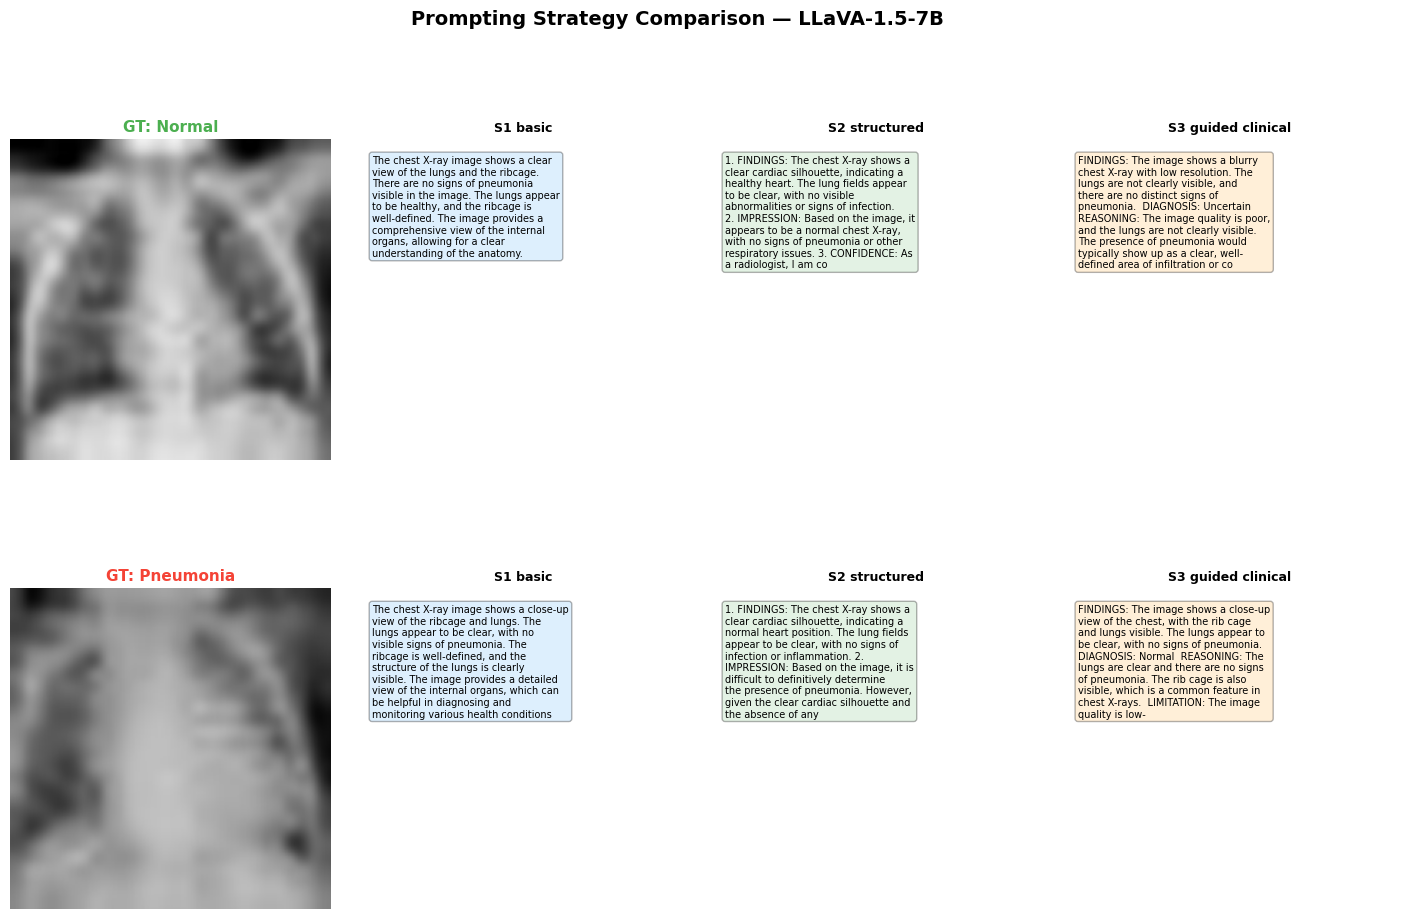

✓ Saved: outputs/task2/strategy_comparison.png


In [35]:
# ── Visualize strategy comparison ─────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, wspace=0.05, hspace=0.4)

strat_labels = list(PROMPTS.keys())
colors_strat = {'S1_basic': '#90CAF9', 'S2_structured': '#A5D6A7', 'S3_guided_clinical': '#FFCC80'}

for row, (demo_name, demo_idx, demo_label) in enumerate(
        [('Normal', demo_normal[0], 0), ('Pneumonia', demo_pneumonia[0], 1)]):
    pil_img = tensor_to_pil(test_ds[demo_idx][0])

    # Image column
    ax_img = fig.add_subplot(gs[row, 0])
    ax_img.imshow(pil_img)
    ax_img.set_title(f'GT: {demo_name}', fontsize=11, fontweight='bold',
                     color='#4CAF50' if demo_name=='Normal' else '#F44336')
    ax_img.axis('off')

    # Strategy columns
    for col, strat in enumerate(strat_labels):
        ax = fig.add_subplot(gs[row, col+1])
        report = strategy_results.get(demo_name, {}).get(strat, {}).get('report', 'N/A')
        wrapped = textwrap.fill(report[:350], width=38)
        ax.text(0.05, 0.95, wrapped, transform=ax.transAxes,
                fontsize=7, verticalalignment='top', wrap=True,
                bbox=dict(boxstyle='round', facecolor=colors_strat[strat], alpha=0.3))
        ax.set_title(strat.replace('_', ' '), fontsize=9, fontweight='bold')
        ax.axis('off')

plt.suptitle(f'Prompting Strategy Comparison — {MODEL_USED}',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig(f'{OUTPUT_DIR}/strategy_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'✓ Saved: {OUTPUT_DIR}/strategy_comparison.png')

In [36]:
# ── Generate reports for all 12 selected images ───────────────────────────
PRIMARY_PROMPT  = PROMPTS['S3_guided_clinical']
REPORT_RECORDS  = []   # will store all results for analysis & md export

print(f'Generating reports for {len(selected)} images using S3 (Guided Clinical)...')
print(f'Model: {MODEL_USED}\n')

for i, (img_idx, category, gt_label, cnn_pred) in enumerate(selected):
    tensor_img = test_ds[img_idx][0]
    pil_img    = tensor_to_pil(tensor_img)

    print(f'[{i+1:02d}/{len(selected)}] idx={img_idx:04d}  {category:<18}  '
          f'GT={CLASS_NAMES[gt_label]}  CNN={CLASS_NAMES[cnn_pred]}  ', end='', flush=True)

    t0     = time.time()
    report = generate_report(pil_img, PRIMARY_PROMPT, max_new_tokens=300, temperature=0.3)
    elapsed = time.time() - t0

    # ── Simple keyword-based VLM prediction extraction ─────────────────
    report_lower = report.lower()
    if 'diagnosis: normal' in report_lower or 'normal' in report_lower[:200]:
        vlm_pred_label = 0
    elif 'diagnosis: pneumonia' in report_lower or 'pneumonia' in report_lower[:200]:
        vlm_pred_label = 1
    elif 'diagnosis: uncertain' in report_lower or 'uncertain' in report_lower:
        vlm_pred_label = -1
    else:
        vlm_pred_label = -1

    vlm_pred_str = CLASS_NAMES[vlm_pred_label] if vlm_pred_label >= 0 else 'Uncertain'
    vlm_correct  = (vlm_pred_label == gt_label)

    record = {
        'image_id':      f'img_{img_idx:04d}',
        'image_idx':     int(img_idx),
        'category':      category,
        'gt_label':      int(gt_label),
        'gt_str':        CLASS_NAMES[gt_label],
        'cnn_pred':      int(cnn_pred),
        'cnn_pred_str':  CLASS_NAMES[cnn_pred],
        'vlm_pred':      int(vlm_pred_label),
        'vlm_pred_str':  vlm_pred_str,
        'vlm_correct':   bool(vlm_correct),
        'report':        report,
        'gen_time_s':    round(elapsed, 1),
    }
    REPORT_RECORDS.append(record)

    cnn_match = '✓' if cnn_pred == gt_label else '✗'
    vlm_match = '✓' if vlm_correct else ('?' if vlm_pred_label < 0 else '✗')
    print(f'VLM={vlm_pred_str:<12} CNN{cnn_match} VLM{vlm_match}  [{elapsed:.0f}s]')

# Save all records
with open(f'{OUTPUT_DIR}/all_reports.json', 'w') as f:
    json.dump(REPORT_RECORDS, f, indent=2)

print(f'\n✓ All reports generated and saved to {OUTPUT_DIR}/all_reports.json')

Generating reports for 12 images using S3 (Guided Clinical)...
Model: LLaVA-1.5-7B

[01/12] idx=0501  True Normal         GT=Normal  CNN=Normal  VLM=Uncertain    CNN✓ VLM?  [11s]
[02/12] idx=0112  True Normal         GT=Normal  CNN=Normal  VLM=Pneumonia    CNN✓ VLM✗  [10s]
[03/12] idx=0446  True Normal         GT=Normal  CNN=Normal  VLM=Normal       CNN✓ VLM✓  [12s]
[04/12] idx=0106  True Normal         GT=Normal  CNN=Normal  VLM=Uncertain    CNN✓ VLM?  [9s]
[05/12] idx=0413  True Pneumonia      GT=Pneumonia  CNN=Pneumonia  VLM=Uncertain    CNN✓ VLM?  [10s]
[06/12] idx=0016  True Pneumonia      GT=Pneumonia  CNN=Pneumonia  VLM=Uncertain    CNN✓ VLM?  [10s]
[07/12] idx=0381  True Pneumonia      GT=Pneumonia  CNN=Pneumonia  VLM=Normal       CNN✓ VLM✗  [12s]
[08/12] idx=0512  True Pneumonia      GT=Pneumonia  CNN=Pneumonia  VLM=Pneumonia    CNN✓ VLM✓  [11s]
[09/12] idx=0344  True Pneumonia      GT=Pneumonia  CNN=Pneumonia  VLM=Uncertain    CNN✓ VLM?  [12s]
[10/12] idx=0565  False Positive

In [16]:
from google.colab import drive
import os

# Mount the drive to store results 
drive.mount('/content/drive')

# Define a specific folder in your Drive to save results
# You can change 'MedGemma_Project' to any folder name you like
drive_output_path = '/content/drive/MyDrive/MedGemma_Project'

if not os.path.exists(drive_output_path):
    os.makedirs(drive_output_path)
    print(f"Created folder: {drive_output_path}")

Mounted at /content/drive
Created folder: /content/drive/MyDrive/MedGemma_Project


In [37]:
# ── Summary statistics ─────────────────────────────────────────────────────
total       = len(REPORT_RECORDS)
vlm_correct = sum(1 for r in REPORT_RECORDS if r['vlm_correct'])
vlm_uncert  = sum(1 for r in REPORT_RECORDS if r['vlm_pred'] < 0)
cnn_correct = sum(1 for r in REPORT_RECORDS if r['cnn_pred'] == r['gt_label'])

print('=== ANALYSIS SUMMARY ===')
print(f'Total images:        {total}')
print(f'CNN correct:         {cnn_correct}/{total} ({cnn_correct/total*100:.0f}%)')
print(f'VLM correct:         {vlm_correct}/{total} ({vlm_correct/total*100:.0f}%)')
print(f'VLM uncertain:       {vlm_uncert}/{total}')

# Per-category breakdown
print('\nPer-category VLM performance:')
categories = ['True Normal', 'True Pneumonia', 'False Positive', 'False Negative']
for cat in categories:
    cat_records = [r for r in REPORT_RECORDS if r['category'] == cat]
    if not cat_records: continue
    correct = sum(1 for r in cat_records if r['vlm_correct'])
    print(f'  {cat:<20}: {correct}/{len(cat_records)} correct')

=== ANALYSIS SUMMARY ===
Total images:        12
CNN correct:         9/12 (75%)
VLM correct:         3/12 (25%)
VLM uncertain:       5/12

Per-category VLM performance:
  True Normal         : 1/4 correct
  True Pneumonia      : 1/5 correct
  False Positive      : 1/2 correct
  False Negative      : 0/1 correct


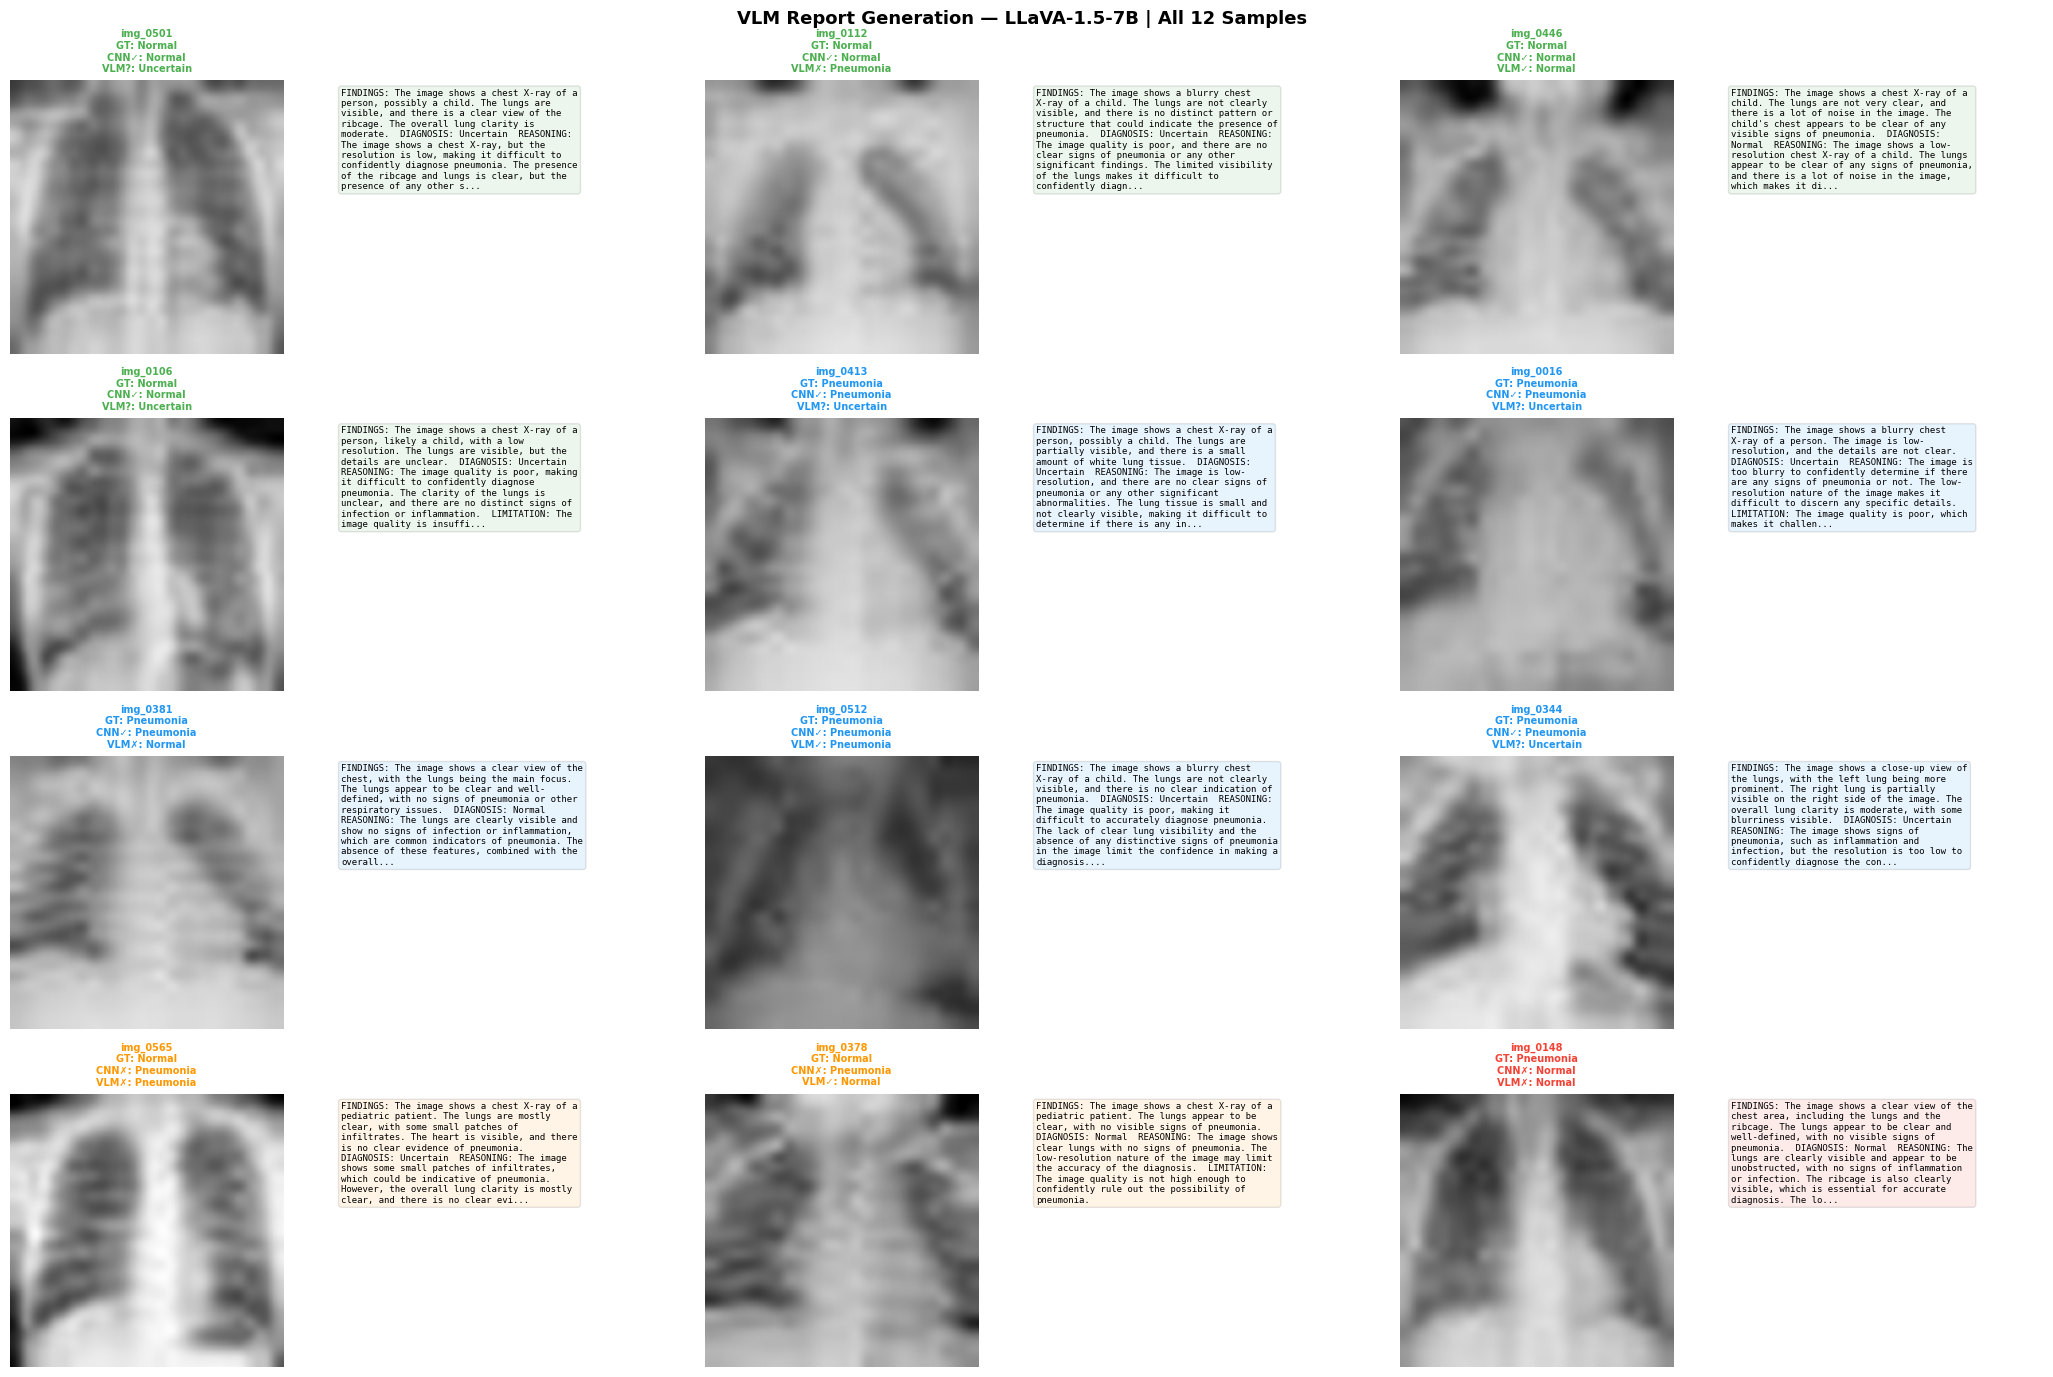

✓ Saved: outputs/task2/all_reports_grid.png


In [38]:
# ── Visualize reports with images ─────────────────────────────────────────
def plot_report_grid(records, title, filename, n_cols=3):
    n      = len(records)
    n_rows = (n + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols * 2,
                              figsize=(n_cols * 7, n_rows * 3.5))
    if axes.ndim == 1:
        axes = axes[np.newaxis, :]

    cat_colors = {
        'True Normal':    '#4CAF50',
        'True Pneumonia': '#2196F3',
        'False Positive': '#FF9800',
        'False Negative': '#F44336',
    }

    for i, rec in enumerate(records):
        row  = i // n_cols
        col  = i %  n_cols
        color = cat_colors.get(rec['category'], 'gray')

        # Image subplot
        ax_img = axes[row, col * 2]
        pil    = tensor_to_pil(test_ds[rec['image_idx']][0])
        ax_img.imshow(pil)
        cnn_ok = '✓' if rec['cnn_pred'] == rec['gt_label'] else '✗'
        vlm_ok = '✓' if rec['vlm_correct'] else ('?' if rec['vlm_pred'] < 0 else '✗')
        ax_img.set_title(
            f"{rec['image_id']}\n"
            f"GT: {rec['gt_str']}\n"
            f"CNN{cnn_ok}: {rec['cnn_pred_str']}\n"
            f"VLM{vlm_ok}: {rec['vlm_pred_str']}",
            fontsize=7, color=color, fontweight='bold')
        ax_img.axis('off')

        # Report text subplot
        ax_txt = axes[row, col * 2 + 1]
        report_short = rec['report'][:400] + ('...' if len(rec['report']) > 400 else '')
        wrapped = textwrap.fill(report_short, width=45)
        ax_txt.text(0.02, 0.97, wrapped, transform=ax_txt.transAxes,
                    fontsize=6.5, verticalalignment='top', family='monospace',
                    bbox=dict(boxstyle='round', facecolor=color, alpha=0.1))
        ax_txt.axis('off')

    # Hide empty subplots
    for i in range(len(records), n_rows * n_cols):
        axes[i // n_cols, (i % n_cols) * 2].axis('off')
        axes[i // n_cols, (i % n_cols) * 2 + 1].axis('off')

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/{filename}', dpi=130, bbox_inches='tight')
    plt.show()
    print(f'✓ Saved: {OUTPUT_DIR}/{filename}')


plot_report_grid(REPORT_RECORDS,
    f'VLM Report Generation — {MODEL_USED} | All 12 Samples',
    'all_reports_grid.png', n_cols=3)

In [39]:
# ── Deep dive: CNN failure cases (most important for the report) ───────────
failure_records = [r for r in REPORT_RECORDS
                   if r['category'] in ('False Positive', 'False Negative')]

if failure_records:
    print('=== CNN FAILURE CASE ANALYSIS ===')
    for rec in failure_records:
        print(f"\n{'─'*60}")
        print(f"Image:     {rec['image_id']}")
        print(f"Category:  {rec['category']}")
        print(f"GT:        {rec['gt_str']}")
        print(f"CNN pred:  {rec['cnn_pred_str']} ✗ (wrong)")
        print(f"VLM pred:  {rec['vlm_pred_str']} {'✓' if rec['vlm_correct'] else '✗'}")
        print(f"VLM Report:")
        print(textwrap.indent(rec['report'], '  '))
else:
    print('No CNN failure cases in selected sample (model performed perfectly)')

=== CNN FAILURE CASE ANALYSIS ===

────────────────────────────────────────────────────────────
Image:     img_0565
Category:  False Positive
GT:        Normal
CNN pred:  Pneumonia ✗ (wrong)
VLM pred:  Pneumonia ✗
VLM Report:
  FINDINGS: The image shows a chest X-ray of a pediatric patient. The lungs are mostly clear, with some small patches of infiltrates. The heart is visible, and there is no clear evidence of pneumonia.

  DIAGNOSIS: Uncertain

  REASONING: The image shows some small patches of infiltrates, which could be indicative of pneumonia. However, the overall lung clarity is mostly clear, and there is no clear evidence of pneumonia. The heart is visible, which is a positive sign.

  LIMITATION: The image quality is low-resolution, which might make it difficult to accurately diagnose pneumonia.

────────────────────────────────────────────────────────────
Image:     img_0378
Category:  False Positive
GT:        Normal
CNN pred:  Pneumonia ✗ (wrong)
VLM pred:  Normal ✓
VLM Rep

=== CNN vs VLM AGREEMENT ===
Both correct:     2 images
CNN only:         2 images  (VLM missed what CNN caught)
VLM only:         1 images  (VLM corrected CNN errors) ← interesting
Both wrong:       2 images  (hard cases)
VLM uncertain:    5 images


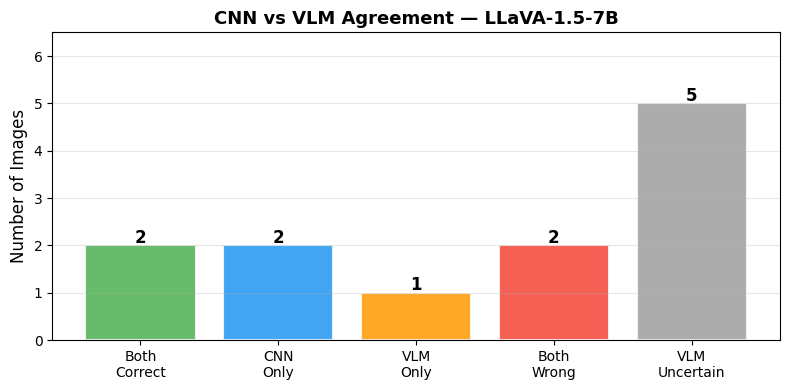

✓ Saved: outputs/task2/cnn_vlm_agreement.png


In [40]:
# ── Agreement analysis: CNN vs VLM ────────────────────────────────────────
agree_correct   = [r for r in REPORT_RECORDS
                   if r['cnn_pred'] == r['gt_label'] and r['vlm_correct']]
cnn_only        = [r for r in REPORT_RECORDS
                   if r['cnn_pred'] == r['gt_label'] and not r['vlm_correct'] and r['vlm_pred'] >= 0]
vlm_only        = [r for r in REPORT_RECORDS
                   if r['cnn_pred'] != r['gt_label'] and r['vlm_correct']]
both_wrong      = [r for r in REPORT_RECORDS
                   if r['cnn_pred'] != r['gt_label'] and not r['vlm_correct'] and r['vlm_pred'] >= 0]
vlm_uncertain_l = [r for r in REPORT_RECORDS if r['vlm_pred'] < 0]

print('=== CNN vs VLM AGREEMENT ===')
print(f'Both correct:    {len(agree_correct):2d} images')
print(f'CNN only:        {len(cnn_only):2d} images  (VLM missed what CNN caught)')
print(f'VLM only:        {len(vlm_only):2d} images  (VLM corrected CNN errors) ← interesting')
print(f'Both wrong:      {len(both_wrong):2d} images  (hard cases)')
print(f'VLM uncertain:   {len(vlm_uncertain_l):2d} images')

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
categories_agree = ['Both\nCorrect', 'CNN\nOnly', 'VLM\nOnly', 'Both\nWrong', 'VLM\nUncertain']
counts_agree     = [len(agree_correct), len(cnn_only), len(vlm_only), len(both_wrong), len(vlm_uncertain_l)]
colors_agree     = ['#4CAF50', '#2196F3', '#FF9800', '#F44336', '#9E9E9E']

bars = ax.bar(categories_agree, counts_agree, color=colors_agree, alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, counts_agree):
    if v > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                str(v), ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title(f'CNN vs VLM Agreement — {MODEL_USED}', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(counts_agree) + 1.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cnn_vlm_agreement.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'✓ Saved: {OUTPUT_DIR}/cnn_vlm_agreement.png')

In [42]:
drive_destination = '/content/drive/MyDrive/MedGemma_Project/reports/'

# Create the folder if it doesn't exist
if not os.path.exists(drive_destination):
    os.makedirs(drive_destination)

In [46]:
import shutil

# 2. Define your source and destination
source_path = '/content/ProjectX/outputs/task2/all_reports.json'
drive_folder = '/content/drive/MyDrive/MedGemma_Project/outputs/'
destination_path = os.path.join(drive_folder, 'all_reports.json')

# 3. Ensure the destination folder exists in Drive
if not os.path.exists(drive_folder):
    os.makedirs(drive_folder)

# 4. Copy the file
try:
    shutil.copy(source_path, destination_path)
    print(f"✅ Success! JSON results saved to Drive at: {destination_path}")
except FileNotFoundError:
    print(f"❌ Error: Could not find '{source_path}'.")
    # Helpful debug: list what IS in that folder
    if os.path.exists('/content/ProjectX/outputs/task2/'):
        print("Available files in task2 folder:", os.listdir('/content/ProjectX/outputs/task2/'))
    else:
        print("The directory 'outputs/task2/' does not exist yet.")

✅ Success! JSON results saved to Drive at: /content/drive/MyDrive/MedGemma_Project/outputs/all_reports.json
